In [1]:
import torch
device = 'mps' if torch.mps.is_available() else 'cpu'

In [2]:
from torch import nn
import matplotlib.pyplot as plt

In [3]:
torch.mps.manual_seed(1234)
weight, bias = 0.7, 0.3
start, end = 0, 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

In [4]:
X[-10:], y[-10:]

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [5]:
train_split = int(0.8 * X.shape[0])
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [6]:
def plot_predictions(
        train_data=X_train, train_labels=y_train, 
        test_data=X_test, test_labels=y_test, 
        predictions=None
    ):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data.cpu(), train_labels.cpu(), c='b', s=4, label='Training dataset')
    plt.scatter(test_data.cpu(), test_labels.cpu(), c='g', s=4, label='Test dataset')
    if predictions is not None:
        plt.scatter(test_data.cpu(), predictions.cpu(), c='r', s=4, label='Predictions')
    plt.legend(prop={'size':14})
    plt.show()

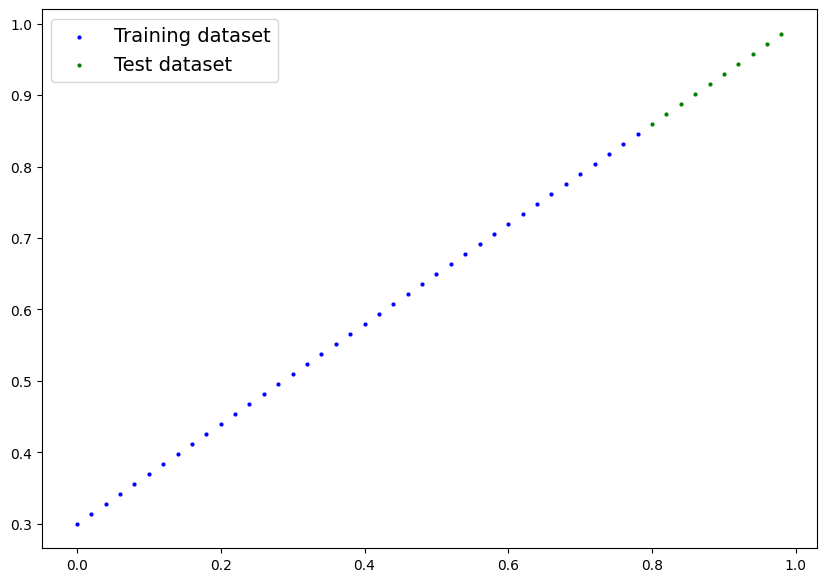

In [7]:
plot_predictions()

In [8]:
torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float),

(tensor([-0.6802]),)

In [9]:
class LinearRegressionModel(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.weights = nn.Parameter(
            torch.randn(1, dtype=torch.float), requires_grad=True
        )
        self.bias = nn.Parameter(
            torch.randn(1, dtype=torch.float), requires_grad=True
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [10]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [12]:
with torch.inference_mode():
    y_preds = model_0(X_test)

In [13]:
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [14]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


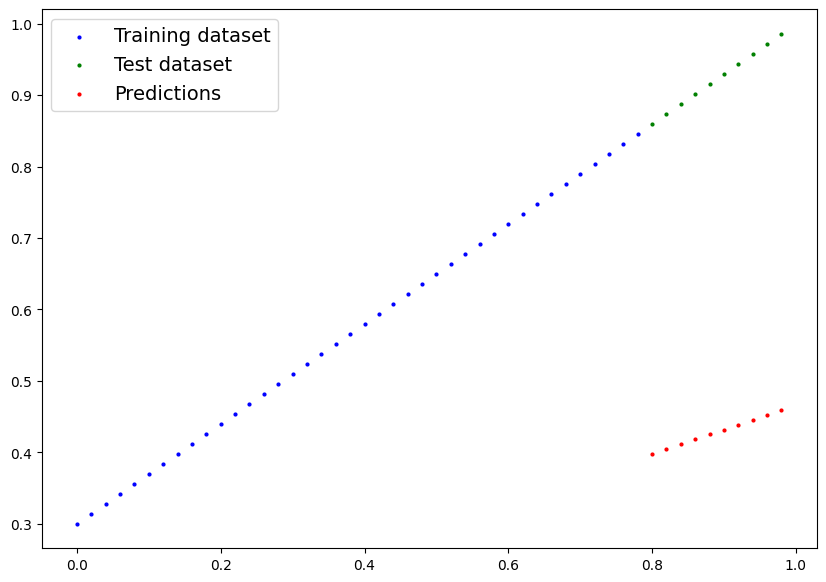

In [15]:
plot_predictions(predictions=y_preds)

In [16]:
loss_function = nn.L1Loss()
optimizer = torch.optim.SGD(
    params=model_0.parameters(), lr=0.01
)

In [17]:
torch.mps.manual_seed(42)
torch.manual_seed(42)

epochs = 120
train_loss_values, test_loss_values = [], []
epoch_count = []

for epoch in range(epochs):

    model_0.train()
    y_pred = model_0(X_train)
    loss = loss_function(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_function(test_pred, y_test)
    
        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())
            print(f'Epoch: {epoch} | Train MAE: {loss} | Test MAE: {test_loss}')

Epoch: 0 | Train MAE: 0.31288135051727295 | Test MAE: 0.48106518387794495
Epoch: 10 | Train MAE: 0.1976713389158249 | Test MAE: 0.3463551998138428
Epoch: 20 | Train MAE: 0.08908725529909134 | Test MAE: 0.2172965705394745
Epoch: 30 | Train MAE: 0.053148530423641205 | Test MAE: 0.14464019238948822
Epoch: 40 | Train MAE: 0.04543796554207802 | Test MAE: 0.11360953748226166
Epoch: 50 | Train MAE: 0.04167863354086876 | Test MAE: 0.09919948130846024
Epoch: 60 | Train MAE: 0.03818932920694351 | Test MAE: 0.08886633813381195
Epoch: 70 | Train MAE: 0.03476089984178543 | Test MAE: 0.0805937722325325
Epoch: 80 | Train MAE: 0.03132382780313492 | Test MAE: 0.07232122868299484
Epoch: 90 | Train MAE: 0.027887403964996338 | Test MAE: 0.06473556160926819
Epoch: 100 | Train MAE: 0.024458955973386765 | Test MAE: 0.056463055312633514
Epoch: 110 | Train MAE: 0.021020209416747093 | Test MAE: 0.04819049686193466


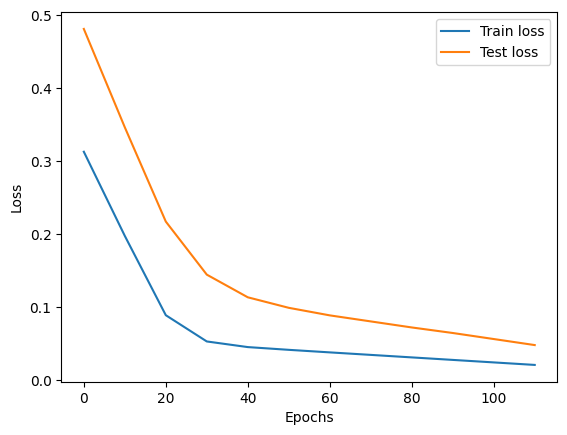

In [18]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6126])), ('bias', tensor([0.3368]))])

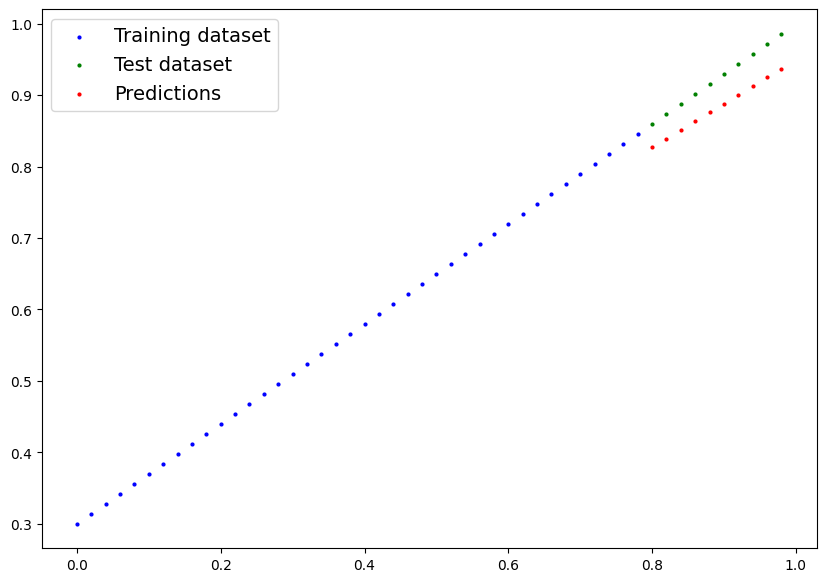

In [20]:
plot_predictions(predictions=test_pred)

In [21]:
model_0.eval()
with torch.inference_mode():
    preds = model_0(X_test)

In [23]:
preds

tensor([[0.8269],
        [0.8391],
        [0.8514],
        [0.8636],
        [0.8759],
        [0.8881],
        [0.9004],
        [0.9126],
        [0.9249],
        [0.9371]])